In [5]:
%pip install seaborn

In [6]:
%pip install pandas

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [10]:
df = pd.read_csv("wine.data")
df.head()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [22]:
column_names = [
    "Customer_Segment",
    "Alcohol",
    "Malic_Acid",
    "Ash",
    "Alcalinity_of_Ash",
    "Magnesium",
    "Total_Phenols",
    "Flavanoids",
    "Nonflavanoid_Phenols",
    "Proanthocyanins",
    "Color_Intensity",
    "Hue",
    "OD280_OD315",
    "Proline"
]
df = pd.read_csv("wine.data", header=None, names=column_names)

In [23]:
df.head()

,Customer_Segment,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [24]:
df.columns

Index(['Customer_Segment', 'Alcohol', 'Malic_Acid', 'Ash', 'Alcalinity_of_Ash',
       'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280_OD315', 'Proline'],
      dtype='str')

In [11]:
df.tail()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840
176,3,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560


In [13]:
df.shape

(177, 14)

In [14]:
df.columns

Index(['1', '14.23', '1.71', '2.43', '15.6', '127', '2.8', '3.06', '.28',
       '2.29', '5.64', '1.04', '3.92', '1065'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       177 non-null    int64  
 1   14.23   177 non-null    float64
 2   1.71    177 non-null    float64
 3   2.43    177 non-null    float64
 4   15.6    177 non-null    float64
 5   127     177 non-null    int64  
 6   2.8     177 non-null    float64
 7   3.06    177 non-null    float64
 8   .28     177 non-null    float64
 9   2.29    177 non-null    float64
 10  5.64    177 non-null    float64
 11  1.04    177 non-null    float64
 12  3.92    177 non-null    float64
 13  1065    177 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.4 KB


In [18]:
df.describe()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,1.943503,12.993672,2.339887,2.366158,19.516949,99.587571,2.292260,2.023446,0.362316,1.586949,5.054802,0.956983,2.604294,745.096045
std,0.773991,0.808808,1.119314,0.275080,3.336071,14.174018,0.626465,0.998658,0.124653,0.571545,2.324446,0.229135,0.705103,314.884046
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.360000,1.600000,2.210000,17.200000,88.000000,1.740000,1.200000,0.270000,1.250000,3.210000,0.780000,1.930000,500.000000
50%,2.000000,13.050000,1.870000,2.360000,19.500000,98.000000,2.350000,2.130000,0.340000,1.550000,4.680000,0.960000,2.780000,672.000000
75%,3.000000,13.670000,3.100000,2.560000,21.500000,107.000000,2.800000,2.860000,0.440000,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.dtypes

In [19]:
df.nunique()

1          3
14.23    125
1.71     133
2.43      78
15.6      62
127       52
2.8       97
3.06     131
.28       39
2.29     101
5.64     131
1.04      78
3.92     121
1065     121
dtype: int64

In [25]:
df["Customer_Segment"].value_counts()

Customer_Segment
2    71
1    59
3    48
Name: count, dtype: int64

<ipython-input-26-1064122905fb>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


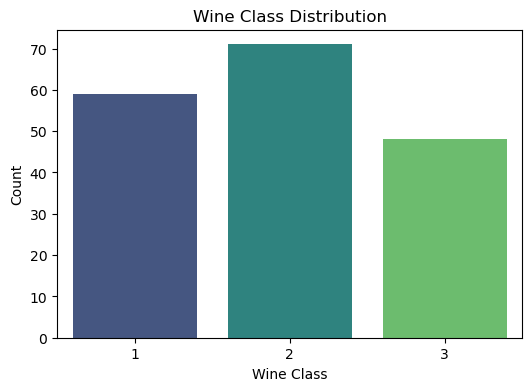

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Customer_Segment",
    data=df,
    palette="viridis"
)
plt.title("Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

In [27]:
# Check missing values
df.isnull().sum()

Customer_Segment        0
Alcohol                 0
Malic_Acid              0
Ash                     0
Alcalinity_of_Ash       0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64

In [28]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


<Figure size 1800x1500 with 0 Axes>

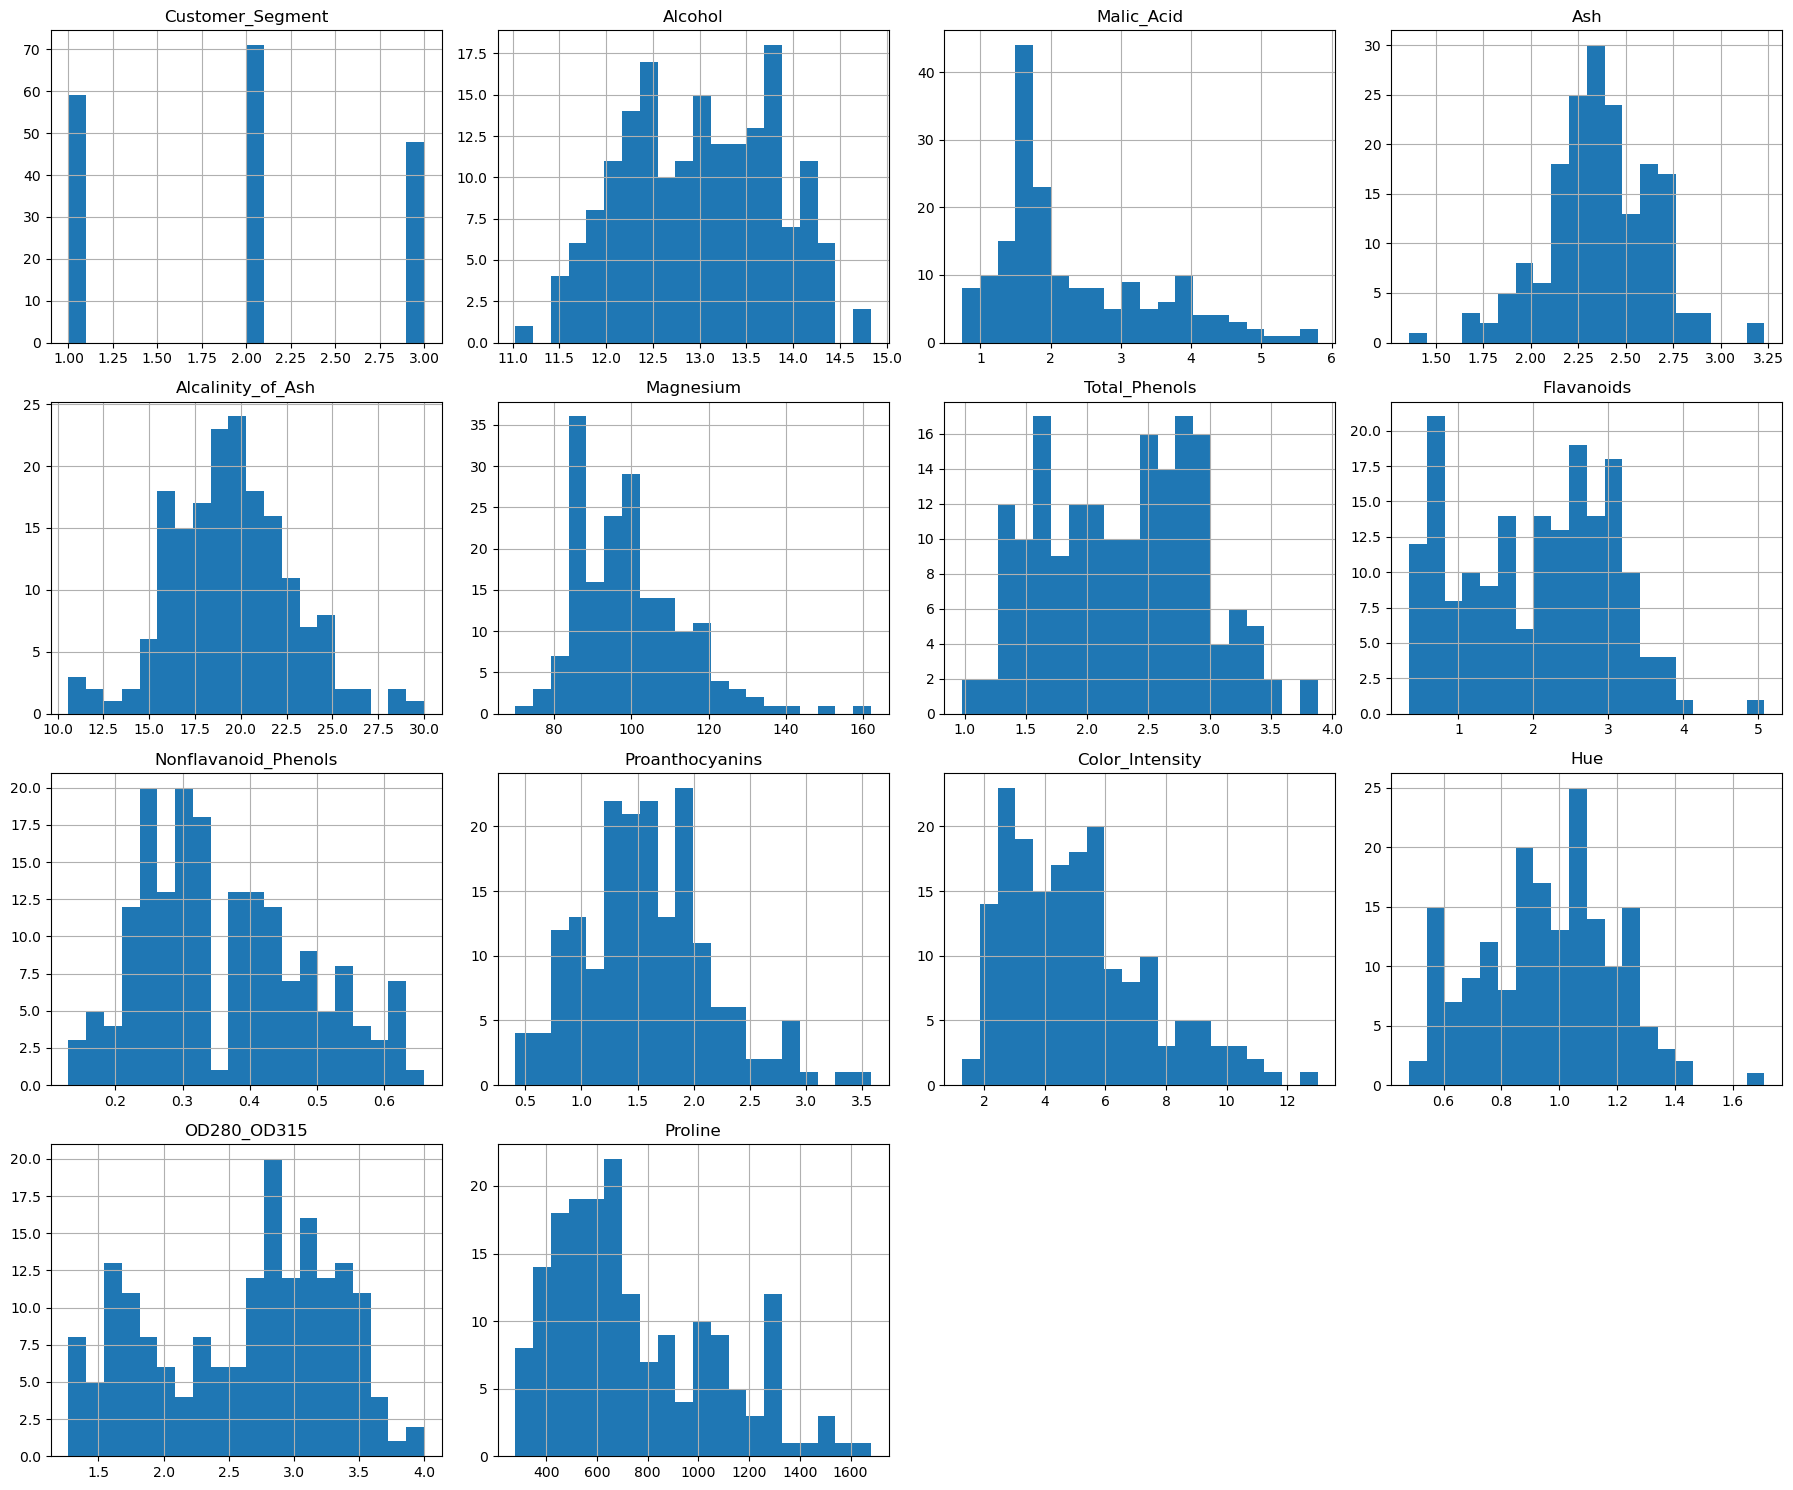

In [29]:
plt.figure(figsize=(18,15))
df.hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

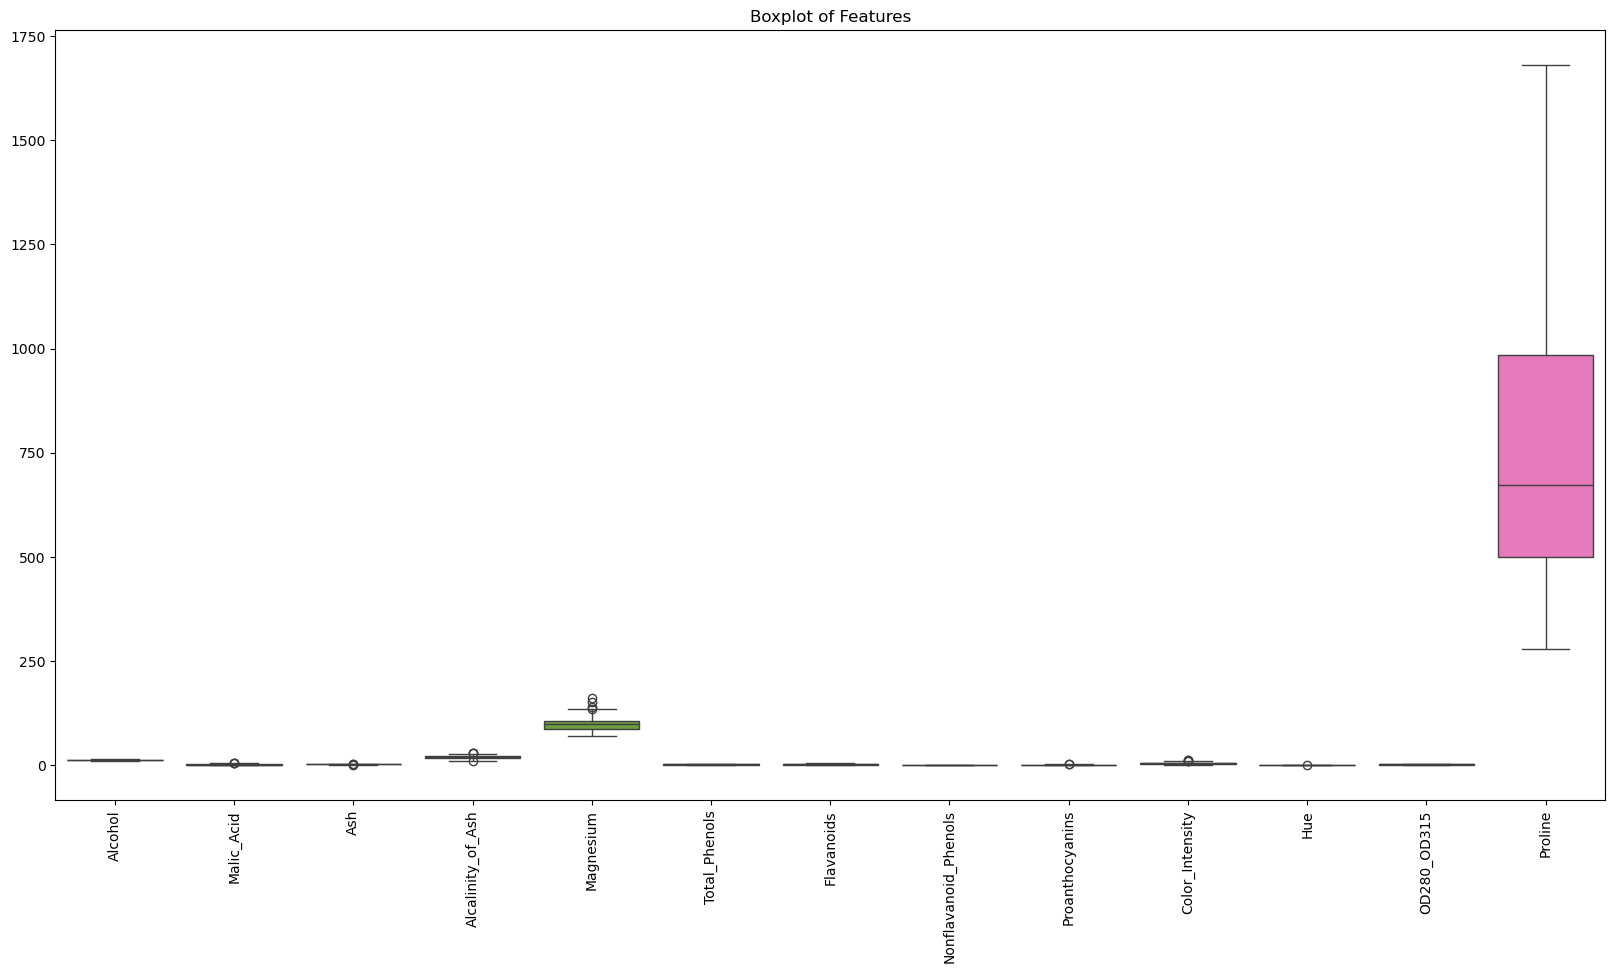

In [30]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df.iloc[:,1:])
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

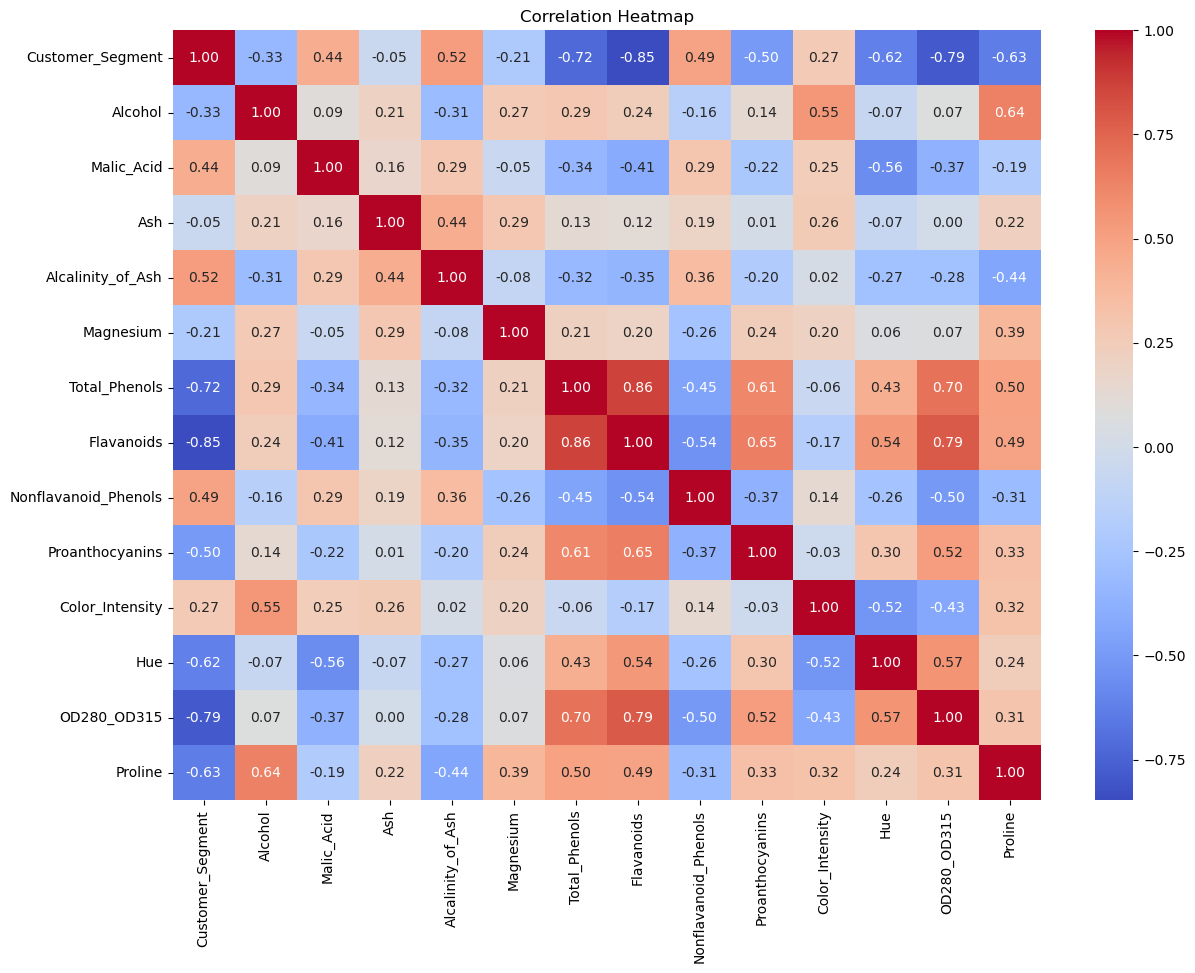

In [39]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

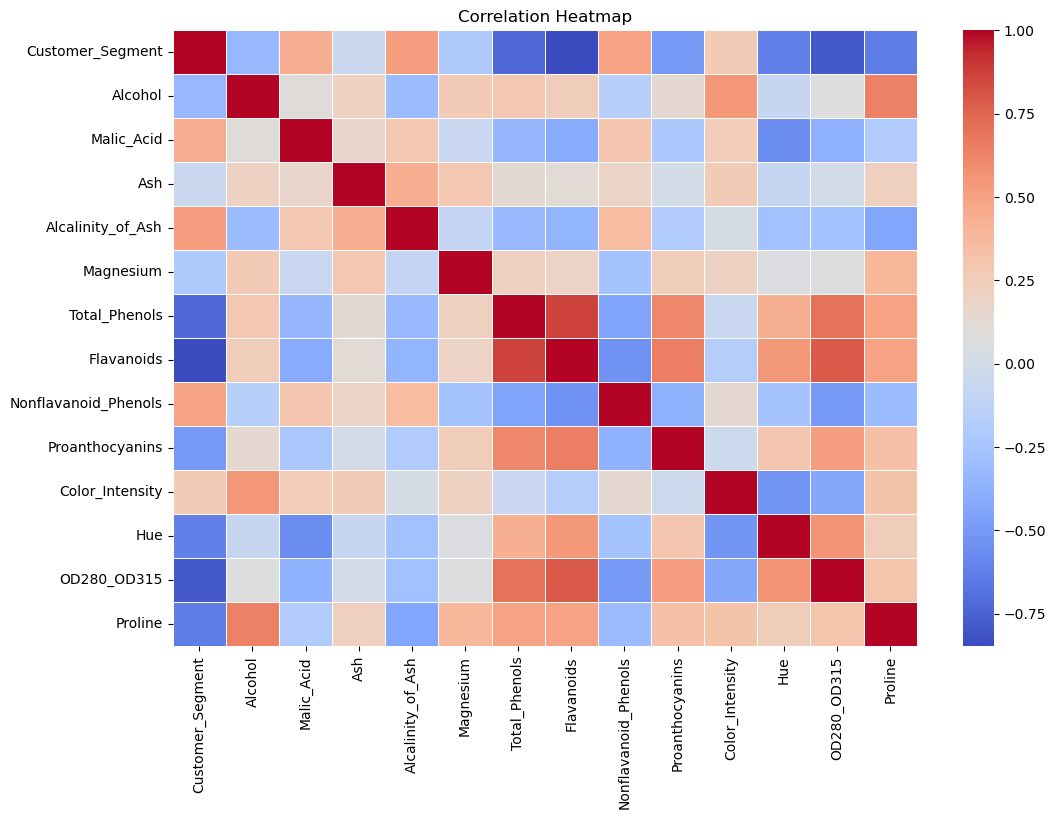

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

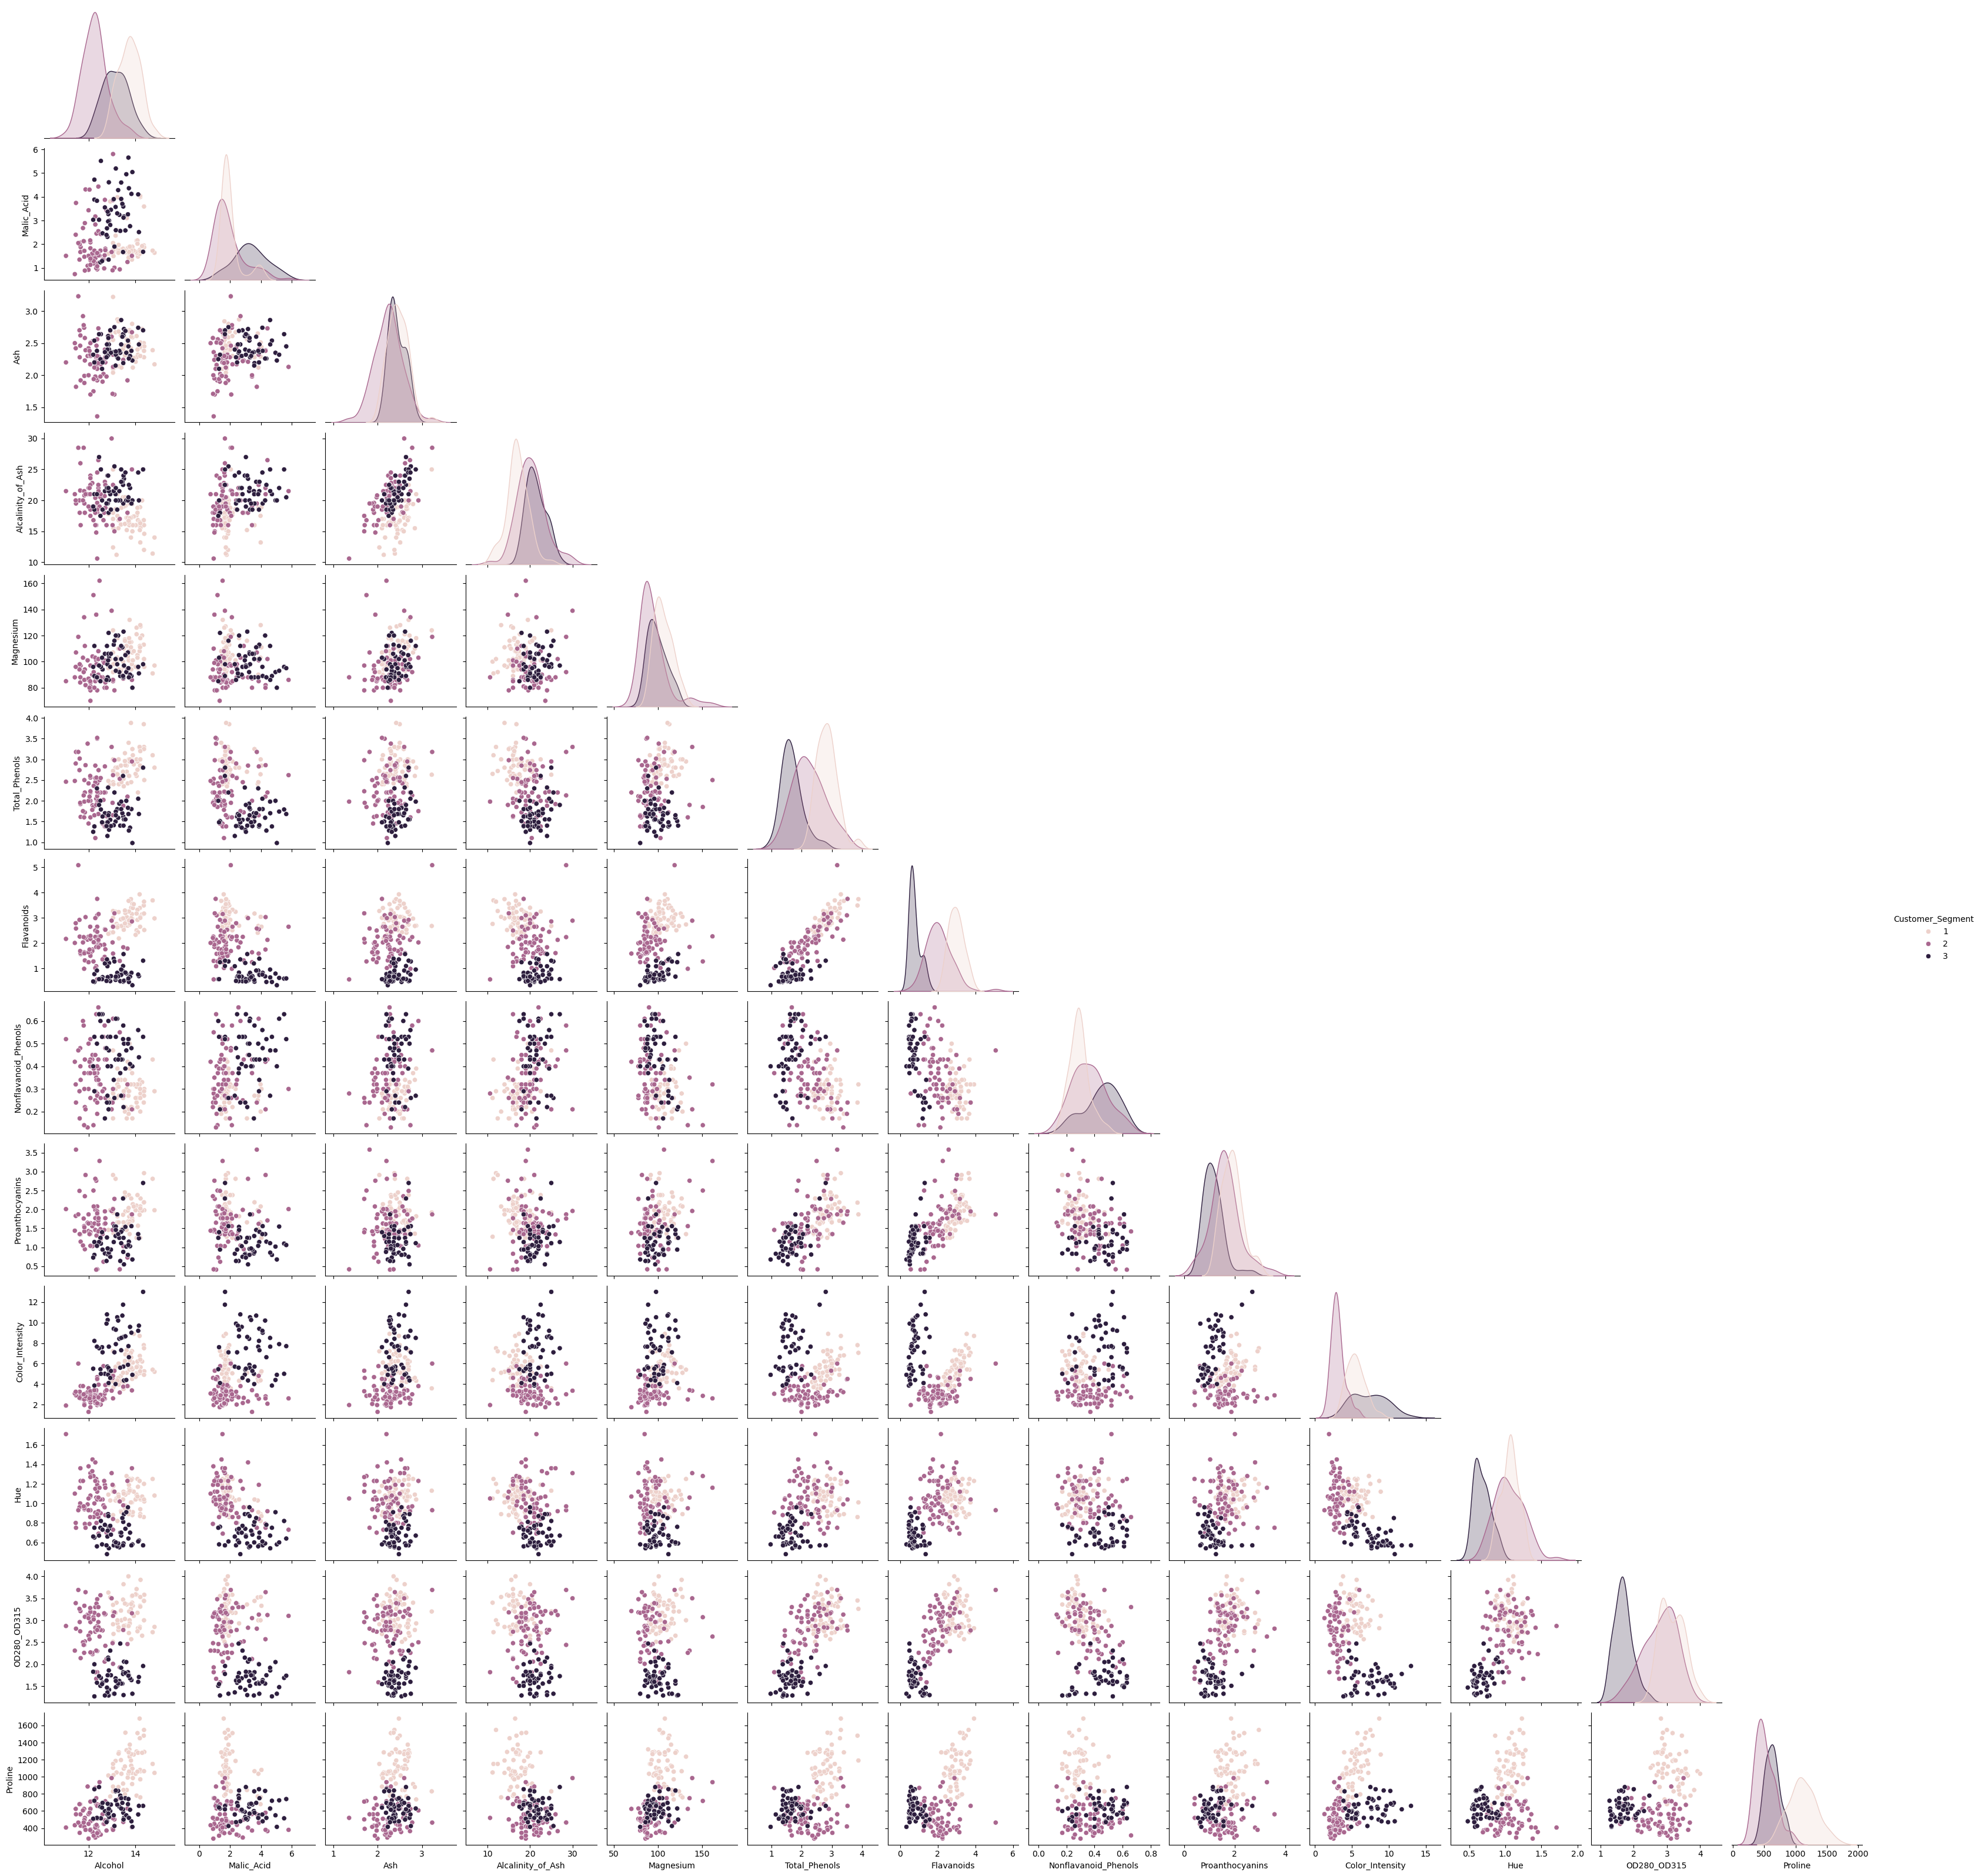

In [47]:
sns.pairplot(
    df,
    hue="Customer_Segment",
    corner=True
)
plt.show()

In [48]:
# Features
X = df.drop("Customer_Segment", axis=1)

# Target
y = df["Customer_Segment"]
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (178, 13)
Target Shape : (178,)


In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


In [50]:
print("Mean :", np.mean(X_scaled))
print("Standard Deviation :", np.std(X_scaled))

Mean : -1.2282501914608474e-16
Standard Deviation : 1.0


In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(178, 2)


In [52]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)
pca_df["Customer_Segment"] = y
pca_df.head()

,Principal Component 1,Principal Component 2,Customer_Segment
0,3.316751,1.443463,1
1,2.209465,-0.333393,1
2,2.516740,1.031151,1
3,3.757066,2.756372,1
4,1.008908,0.869831,1


In [53]:
print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)

Explained Variance Ratio
[0.36198848 0.1920749 ]


In [54]:
print(
    "Total Explained Variance :",
    np.sum(pca.explained_variance_ratio_)
)

Total Explained Variance : 0.5540633835693526


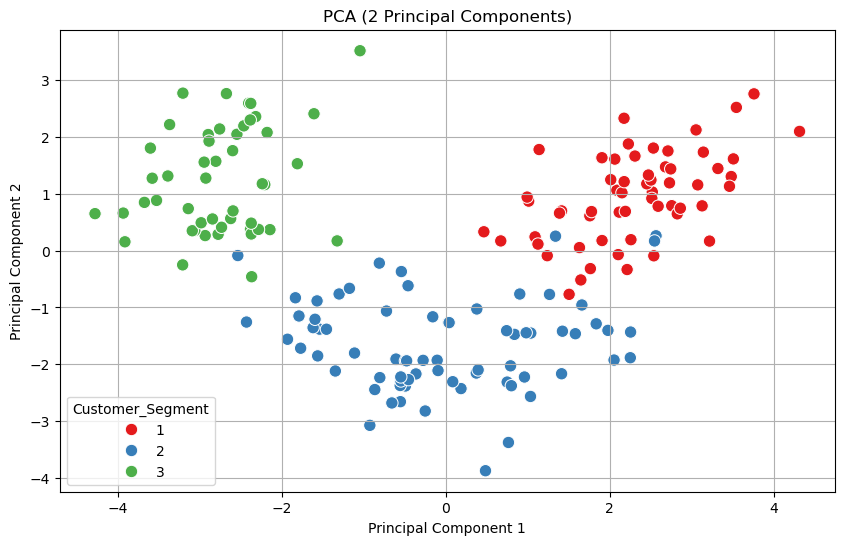

In [55]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Customer_Segment",
    palette="Set1",
    s=80
)
plt.title("PCA (2 Principal Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

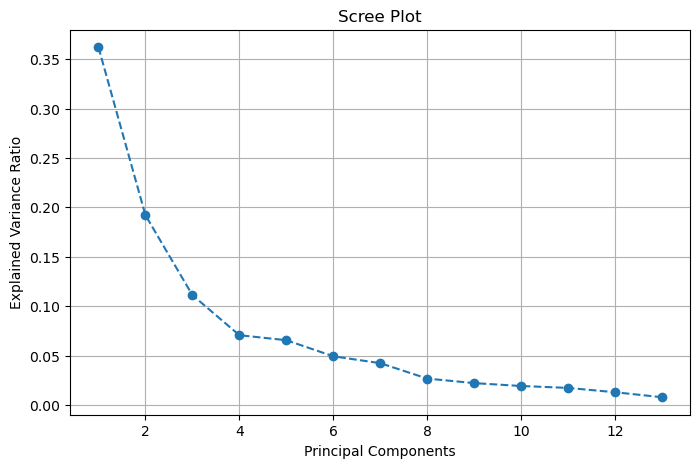

In [56]:
# Apply PCA on all components
pca_full = PCA()
pca_full.fit(X_scaled)
# Plot Explained Variance
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker='o',
    linestyle='--'
)
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

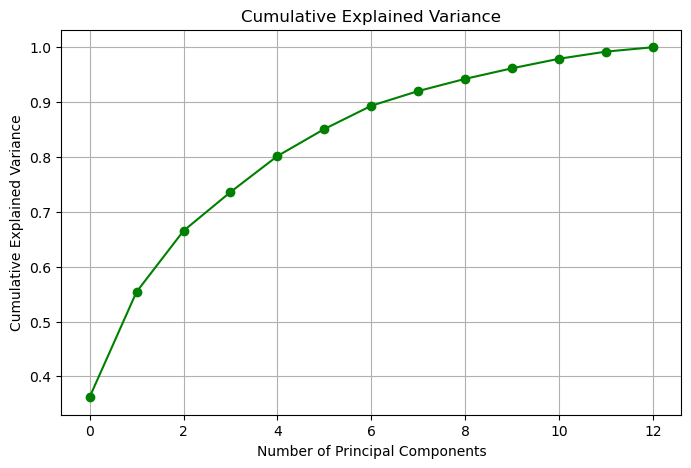

In [57]:
plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_),
    marker='o',
    color='green'
)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [58]:
from mpl_toolkits.mplot3d import Axes3D

In [59]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

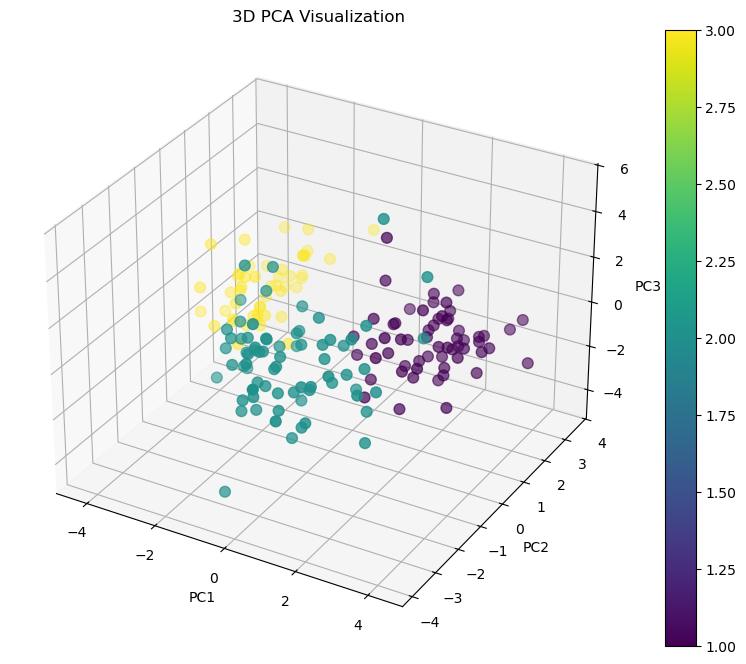

In [60]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=y,
    cmap='viridis',
    s=60
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Visualization")
plt.colorbar(scatter)
plt.show()

In [61]:
print("Original Dataset Shape :", X.shape)
print("After PCA Shape :", X_pca.shape)

Original Dataset Shape : (178, 13)
After PCA Shape : (178, 2)


In [62]:
variance = pd.DataFrame({
    "Principal Component": ["PC1","PC2"],
    "Explained Variance": pca.explained_variance_ratio_
})
variance

,Principal Component,Explained Variance
0,PC1,0.361988
1,PC2,0.192075


In [ ]:
"""
================ PCA CONCLUSION ================

1. The original dataset contains 13 numerical features.

2. StandardScaler was used before PCA because
   PCA is sensitive to different feature scales.

3. PCA reduced the dimensionality from
   13 features to 2 principal components.

4. The first two principal components retain
   most of the important information.

5. PCA makes visualization easier while reducing
   computational complexity.

6. PCA is widely used for
   - Data Compression
   - Noise Reduction
   - Data Visualization
   - Feature Extraction

===============================================
"""